# 06-1 군집 알고리즘 (Clustering) (1)

In [42]:
import numpy as np
import matplotlib.pyplot as plt


In [43]:
#파일로드
fruits=np.load('./data/fruits_300.npy')

In [44]:
fruits.shape

(300, 100, 100)

In [45]:
#차원, 행, 열
#300: 사진개수
#100: 이미지 높이
#100: 이미지 너비

#100*100 이미지 300장


In [46]:
fruits.ndim

3

In [47]:
z= np.arange(36).reshape(3,4,3)
z

array([[[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]],

       [[12, 13, 14],
        [15, 16, 17],
        [18, 19, 20],
        [21, 22, 23]],

       [[24, 25, 26],
        [27, 28, 29],
        [30, 31, 32],
        [33, 34, 35]]])

In [48]:
#첫번째 행의 모든 데이터를 출력하고 싶다면
z[0,0,:]

array([0, 1, 2])

In [49]:
z[2,1,:]

array([27, 28, 29])

### 과일이미지의 첫번째 행 출력

In [50]:
fruits[0,0,:]

array([  1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   2,   1,   2,   2,   2,   2,   2,   2,   1,   1,
         1,   1,   1,   1,   1,   1,   2,   3,   2,   1,   2,   1,   1,
         1,   1,   2,   1,   3,   2,   1,   3,   1,   4,   1,   2,   5,
         5,   5,  19, 148, 192, 117,  28,   1,   1,   2,   1,   4,   1,
         1,   3,   1,   1,   1,   1,   1,   2,   2,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,   1,
         1,   1,   1,   1,   1,   1,   1,   1,   1], dtype=uint8)

In [51]:
# 0 → 검정
# 255 → 흰색



# 이미지 확인

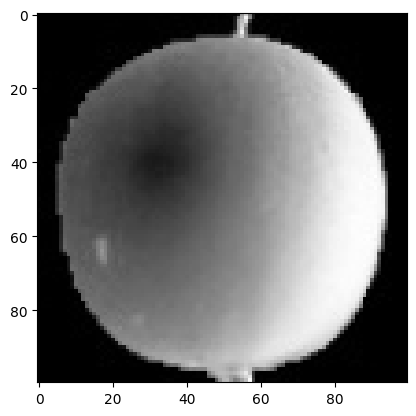

In [52]:
plt.imshow(fruits[0],cmap='gray')
plt.show()

#imshow()는 이미지 배열을 화면에 보여주는 함수이다. 
#숫자배열을 그림으로 보여줌
#반전시킨 이유는 알고리즘은 어떤 출력을 만들기 위해 곱셈, 덧셈을 한다.
#픽셀값이 0이면 출력값도 0이되어 의미가 없다.
#픽셀값이 높으면 출력값도 커지므로 의미를 부여하기 좋다.
#만약 바탕이 흰색이고 사과가 검은색이라면 알고리즘은 흰색인 바탕에 집중하게 된다.
#우리에게 중요한 것은 사과이미지이므로 반전시킨 것이다. 

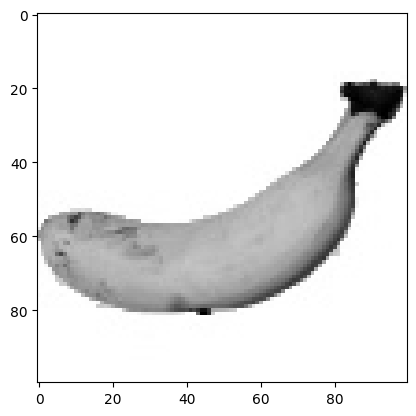

In [55]:
plt.imshow(fruits[299],cmap='gray_r')
plt.show()

In [ ]:
# for i in range(len(fruits)):
#     plt.imshow(fruits[i])
#     plt.show()

In [ ]:
fruits[:,50,:]

array([[  5,   1,   1, ...,   1,   1,   1],
       [  2,  77,  82, ..., 184,  44,   3],
       [  1,   1,   1, ...,   1,   1,   1],
       ...,
       [ 74, 159, 214, ..., 171, 146,  73],
       [  1,   1,   1, ...,   1,   1,   1],
       [  1,   3,   1, ...,   1,   1,   1]], shape=(300, 100), dtype=uint8)

In [ ]:
fruits[100,:,:]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(100, 100), dtype=uint8)

In [ ]:
fruits[100]

array([[1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       ...,
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1],
       [1, 1, 1, ..., 1, 1, 1]], shape=(100, 100), dtype=uint8)

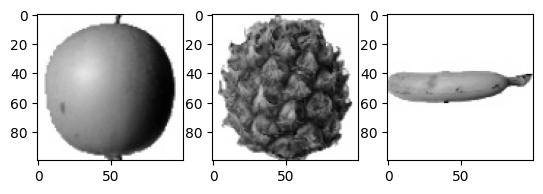

In [ ]:
fig, axs=plt.subplots(1,3)
axs[0].imshow(fruits[0,:,:],cmap='gray_r')
axs[1].imshow(fruits[100],cmap='gray_r')
axs[2].imshow(fruits[200],cmap='gray_r')

In [ ]:
print(np.max(fruits))

255


In [ ]:
fruits.shape

(300, 100, 100)

In [ ]:
fruits.reshape(-1)

array([1, 1, 1, ..., 1, 1, 1], shape=(3000000,), dtype=uint8)

### 3차원을 2차원으로 만들기 연습

In [ ]:
z.shape

(3, 4, 3)

In [ ]:
z1=z.reshape(-1,4*3)
z1, 

(array([[ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11],
        [12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23],
        [24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35]]),)

In [ ]:
p.shape

NameError: name 'p' is not defined

In [ ]:
#셈플 차원 변경하기,
apple=fruits[0:100].reshape(-1,100*100)
pineapple=fruits[100:200].reshape(-1,100*100)
banana=fruits[200:300].reshape(-1,100*100)
apple.ndim, pineapple.ndim,banana.ndim

(2, 2, 2)

In [ ]:
# 사과이미지 셈플100개에 대한 픽셀 평균값 계산, 이미지의 평균,  사과 하나당 만개의 픽셀이 있음. 맨 뒤의 행이 하나생기고(axis=1) 그행에 평균이 생김
apple.mean(axis=1)

array([ 88.3346,  97.9249,  87.3709,  98.3703,  92.8705,  82.6439,
        94.4244,  95.5999,  90.681 ,  81.6226,  87.0578,  95.0745,
        93.8416,  87.017 ,  97.5078,  87.2019,  88.9827, 100.9158,
        92.7823, 100.9184, 104.9854,  88.674 ,  99.5643,  97.2495,
        94.1179,  92.1935,  95.1671,  93.3322, 102.8967,  94.6695,
        90.5285,  89.0744,  97.7641,  97.2938, 100.7564,  90.5236,
       100.2542,  85.8452,  96.4615,  97.1492,  90.711 , 102.3193,
        87.1629,  89.8751,  86.7327,  86.3991,  95.2865,  89.1709,
        96.8163,  91.6604,  96.1065,  99.6829,  94.9718,  87.4812,
        89.2596,  89.5268,  93.799 ,  97.3983,  87.151 ,  97.825 ,
       103.22  ,  94.4239,  83.6657,  83.5159, 102.8453,  87.0379,
        91.2742, 100.4848,  93.8388,  90.8568,  97.4616,  97.5022,
        82.446 ,  87.1789,  96.9206,  90.3135,  90.565 ,  97.6538,
        98.0919,  93.6252,  87.3867,  84.7073,  89.1135,  86.7646,
        88.7301,  86.643 ,  96.7323,  97.2604,  81.9424,  87.1

In [ ]:
apple

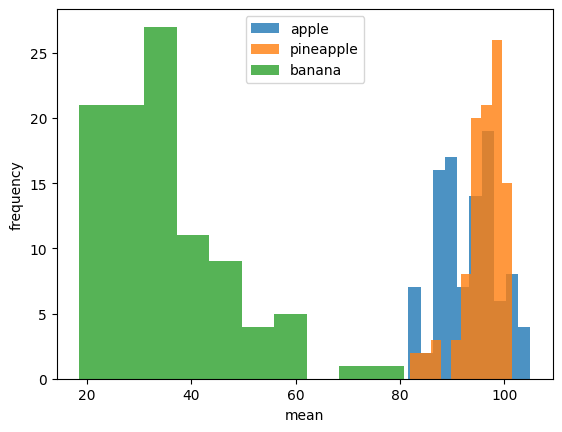

In [ ]:
#평균값으로 히스토그램 그리기
plt.hist(np.mean(apple,axis=1),alpha=0.8)
plt.hist(np.mean(pineapple,axis=1),alpha=0.8)
plt.hist(np.mean(banana,axis=1),alpha=0.8)
plt.legend(['apple','pineapple','banana'])
plt.xlabel('mean')
plt.ylabel('frequency')
plt.show()

#바나나 평균은 60이하에 집중, 사과와 파인애플은 80-90사이

In [ ]:
banana.mean(axis=1)

array([19.5487, 24.4884, 36.7517, 18.568 , 53.572 , 31.5789, 51.9062,
       28.4703, 23.7856, 32.1295, 29.1737, 24.5578, 27.7676, 41.3082,
       61.0437, 32.6444, 38.4187, 30.4175, 30.0639, 21.4994, 32.6018,
       39.6335, 47.8397, 57.7484, 33.6511, 23.5018, 49.6817, 44.0855,
       46.1559, 33.4963, 36.0099, 69.0751, 33.9575, 32.8786, 60.1911,
       32.9949, 45.3359, 56.1694, 36.9218, 25.6754, 32.7901, 29.0245,
       57.7134, 44.6563, 31.2138, 29.836 , 40.9228, 23.7501, 43.1543,
       32.3716, 26.0986, 55.6189, 22.2269, 29.5089, 24.0435, 22.6247,
       24.1709, 46.2714, 32.0763, 42.5076, 44.5522, 24.0199, 27.68  ,
       32.4377, 19.2198, 22.5083, 19.6742, 26.1852, 25.8368, 25.2676,
       26.4721, 34.8503, 28.5235, 80.8545, 36.9371, 47.3975, 18.7909,
       33.0428, 37.8222, 34.7819, 33.6051, 24.3963, 32.7988, 19.7609,
       32.538 , 28.5407, 23.0999, 26.3778, 27.1965, 38.7848, 18.7648,
       30.2297, 54.3816, 37.9073, 32.3126, 31.0664, 33.1657, 37.6051,
       38.1806, 26.2

# 이미지 평균이 아니라 픽셀 위치 평균을 비교해보자

Text(0.5, 1.0, 'Banana')

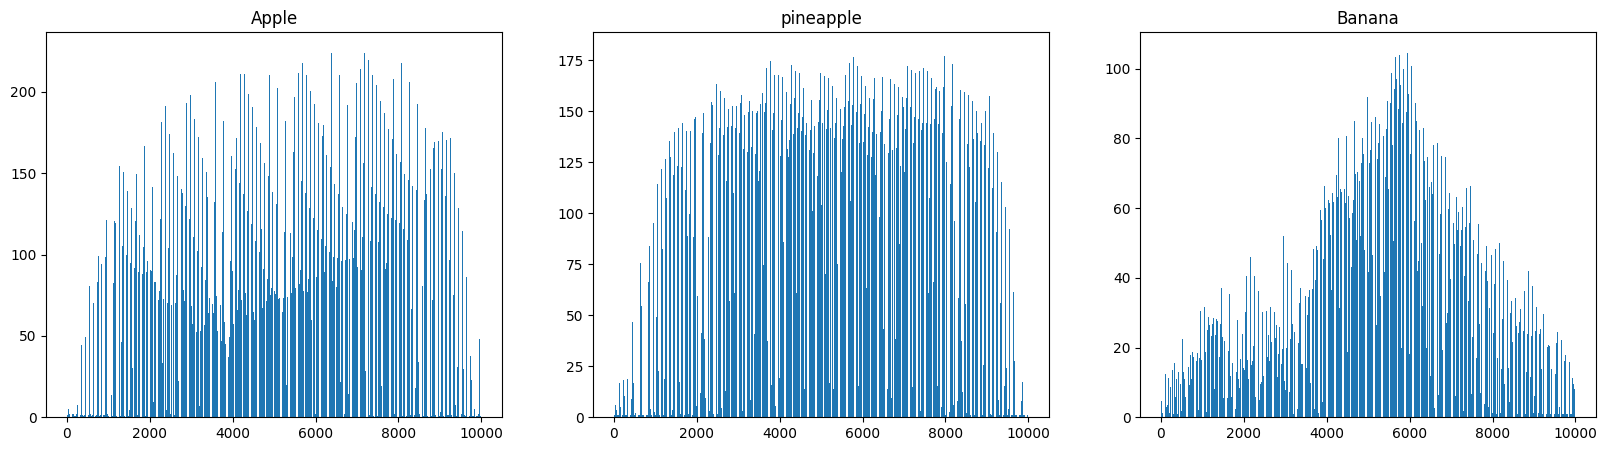

In [ ]:
#이미지 평균이 아니라 픽셀 위치 평균을 비교해 보자
fig, axs=plt.subplots(1,3, figsize=(20,5))
axs[0].bar(range(10000),np.mean(apple,axis=0))
axs[0].set_title('Apple')
axs[1].bar(range(10000),np.mean(pineapple,axis=0))
axs[1].set_title('pineapple')
axs[2].bar(range(10000),np.mean(banana,axis=0))
axs[2].set_title('Banana')

In [ ]:
np.mean(apple,axis=0)#10,000픽셀을 가지고 있는 사과 세로픽셀값의 평균 내기 그러나 1차원
np.mean(apple,axis=0).reshape(100,100) #그래서 이걸 2차원으로 바꾸어 줘라. 

array([1.01, 1.01, 1.01, ..., 1.  , 1.  , 1.  ], shape=(10000,))

##픽셀 평균값을 100*100크기로 바궛 이미지처럼 출력하여 위 그래프와 비교해보자

In [ ]:
apple_mean=np.mean(apple, axis=0).reshape(100,100)
pineapple_mean=np.mean(pineapple,axis=0).reshape(100,100)
banana_mean=np.mean(banana,axis=0).reshape(100,100)
apple_mean, pineapple_mean,banana_mean

(array([[1.01, 1.01, 1.01, ..., 1.  , 1.  , 1.  ],
        [1.01, 1.01, 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        ...,
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]], shape=(100, 100)),
 array([[1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        ...,
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.],
        [1., 1., 1., ..., 1., 1., 1.]], shape=(100, 100)),
 array([[1.1 , 1.07, 1.1 , ..., 1.04, 1.01, 1.05],
        [1.12, 1.03, 1.04, ..., 1.  , 1.01, 1.  ],
        [1.06, 1.02, 1.02, ..., 1.  , 1.05, 1.  ],
        ...,
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
        [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]], shape=(100, 100)))

In [ ]:
fruits.shape

(300, 100, 100)

In [ ]:
apple_mean.shape

(100, 100)

# 평균값과 가까운 사진 찾기


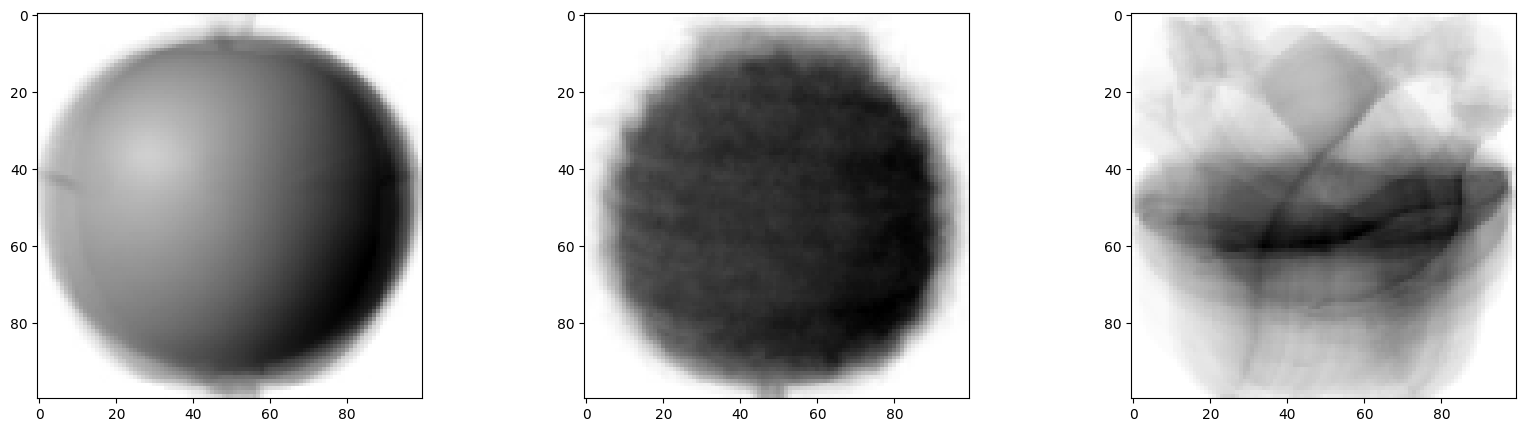

In [ ]:
fig, axs=plt.subplots(1,3,figsize=(20,5))
axs[0].imshow(apple_mean,cmap='gray_r')
axs[1].imshow(pineapple_mean,cmap='gray_r')
axs[2].imshow(banana_mean,cmap='gray_r')

In [ ]:
#세 과일은 픽셀 위치에 따라 값의 크기가 차이가 난다.
#따라서 이 대표 이미지와 가까운 사진을 골라낸다면 사고, 파인애플, 바나나를 구분할 수 있지 않을까!

# 평균과 가장 비슷한 이미지 찾기 
- 차이계산

In [ ]:
#사진 사과의 평균값인 apple-mean과 가장 가까운 사진을 골라보자
#furits배열에 있는 모든 샘플에서 apple_mean을 뺀 절댓값의 평균을 계산하면 된다. 
abs_diff=np.abs(fruits-apple_mean)
abs_diff.shape
#3차원 100행 100열 크기의 배열 

(300, 100, 100)

In [ ]:
abs_mean=np.mean(abs_diff, axis=(1,2))#2차원(행,열)의 평균값을 구한다. 300개
abs_mean.shape
#1차원, 300개의 원소
#이미지(300장)에 대해, 그 이미지의 모든 픽셀의 평균값

(300,)

In [ ]:
#abs_mean값이 가장 작은 것을 찾아 작은것부터 나열한 후 100개를 반환
apple_index=np.argsort(abs_mean)[:100]

In [ ]:
apple_index[1]

np.int64(48)

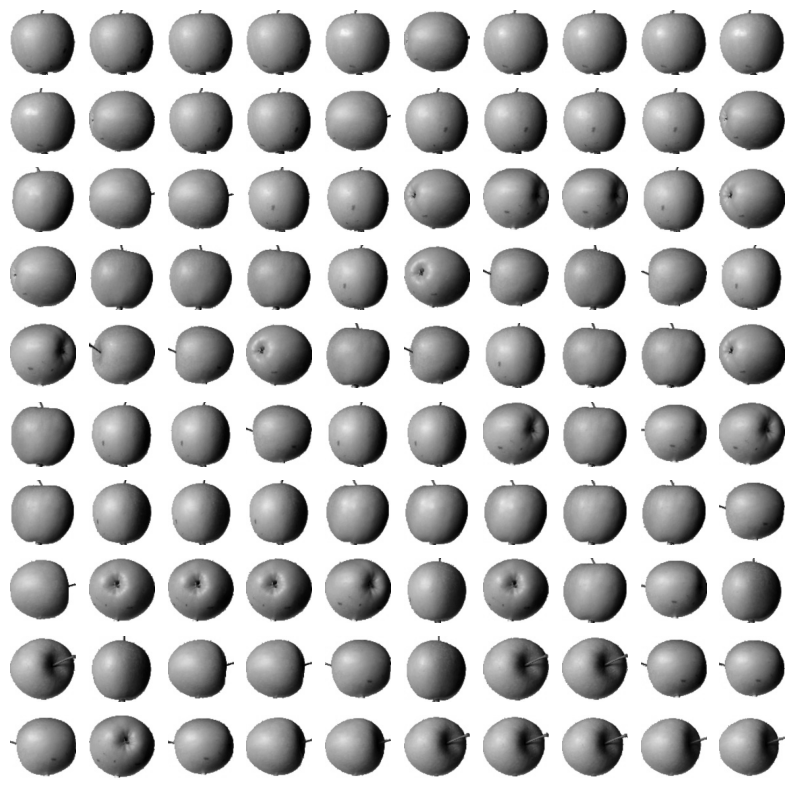

In [ ]:
fig, axs=plt.subplots(10,10,figsize=(10,10))

for i, ax in enumerate(axs.flat):
    ax.imshow(fruits[apple_index[i]], cmap='gray_r')
    ax.axis('off')
plt.show()

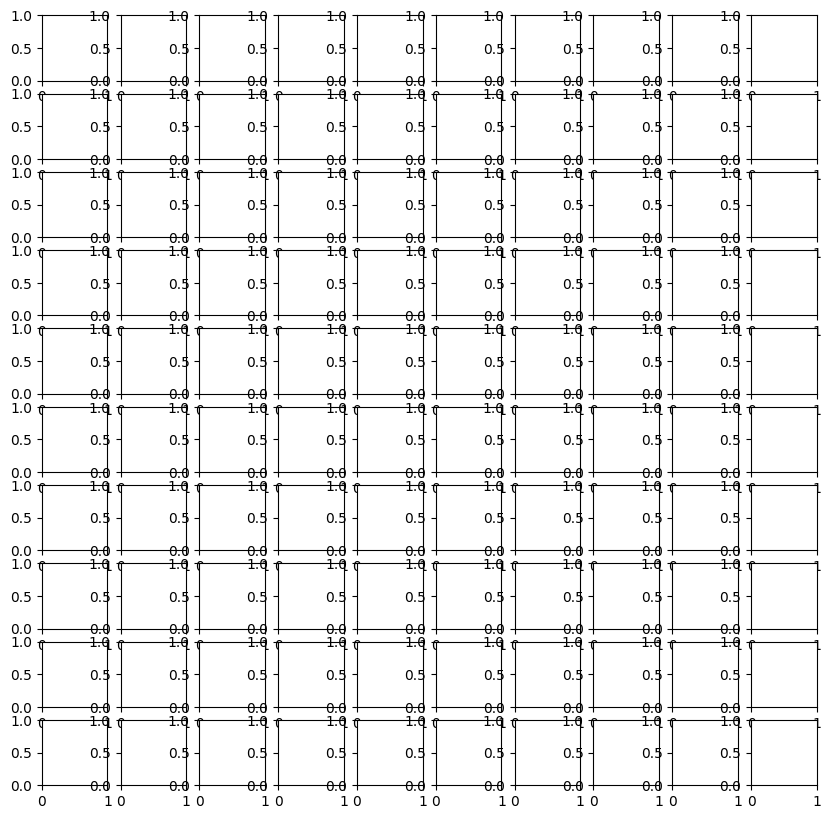

In [ ]:
fix, axs=plt.subplots(10,10,figsize=(10,10))
axs.flat

# 이미지 평균 밝기 계산

In [ ]:
import numpy as np
apple_mean = np.mean(fruits[:100], axis=(1,2))
pineapple_mean = np.mean(fruits[100:200], axis=(1,2))
banana_mean = np.mean(fruits[200:], axis=(1,2))

# axis=(1,2) 가로+세로 픽셀을 평균냄 => 즉 이미지 1장의 평균

In [ ]:
fruits.shape

(300, 100, 100)

In [ ]:
apple_mean.shape

(100,)

In [ ]:
# 1차원이므로 이미지를 그릴 수 없고 boxplot, hist, scatter로 그릴 수 있다. 

In [ ]:
apple_mean

array([ 88.3346,  97.9249,  87.3709,  98.3703,  92.8705,  82.6439,
        94.4244,  95.5999,  90.681 ,  81.6226,  87.0578,  95.0745,
        93.8416,  87.017 ,  97.5078,  87.2019,  88.9827, 100.9158,
        92.7823, 100.9184, 104.9854,  88.674 ,  99.5643,  97.2495,
        94.1179,  92.1935,  95.1671,  93.3322, 102.8967,  94.6695,
        90.5285,  89.0744,  97.7641,  97.2938, 100.7564,  90.5236,
       100.2542,  85.8452,  96.4615,  97.1492,  90.711 , 102.3193,
        87.1629,  89.8751,  86.7327,  86.3991,  95.2865,  89.1709,
        96.8163,  91.6604,  96.1065,  99.6829,  94.9718,  87.4812,
        89.2596,  89.5268,  93.799 ,  97.3983,  87.151 ,  97.825 ,
       103.22  ,  94.4239,  83.6657,  83.5159, 102.8453,  87.0379,
        91.2742, 100.4848,  93.8388,  90.8568,  97.4616,  97.5022,
        82.446 ,  87.1789,  96.9206,  90.3135,  90.565 ,  97.6538,
        98.0919,  93.6252,  87.3867,  84.7073,  89.1135,  86.7646,
        88.7301,  86.643 ,  96.7323,  97.2604,  81.9424,  87.1

# 3차원에서 계산 하기 &&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&&

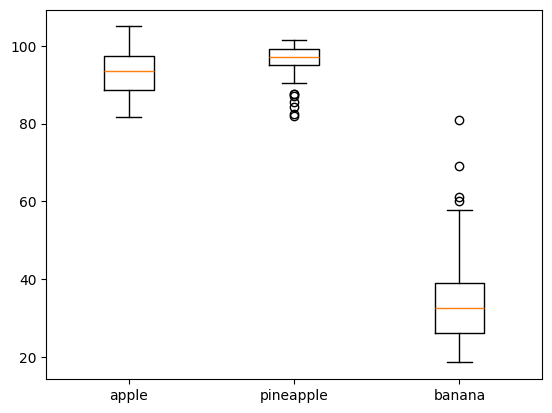

In [ ]:
#3차원을 그대로 계산하기
import matplotlib.pyplot as plt
plt.boxplot([apple_mean, pineapple_mean,banana_mean])
plt.xticks([1,2,3],['apple','pineapple','banana'])
plt.show()

# 평균값과 가까운 사진 찾기

In [57]:
#평균이미지 만들기 3차원에서 바로 게산하기
apple_mean = np.mean(fruits[:100], axis=0)
pineapple_mean = np.mean(fruits[100:200], axis=0)
banana_mean = np.mean(fruits[200:], axis=0)
apple_mean



array([[1.01, 1.01, 1.01, ..., 1.  , 1.  , 1.  ],
       [1.01, 1.01, 1.  , ..., 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
       ...,
       [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ],
       [1.  , 1.  , 1.  , ..., 1.  , 1.  , 1.  ]], shape=(100, 100))

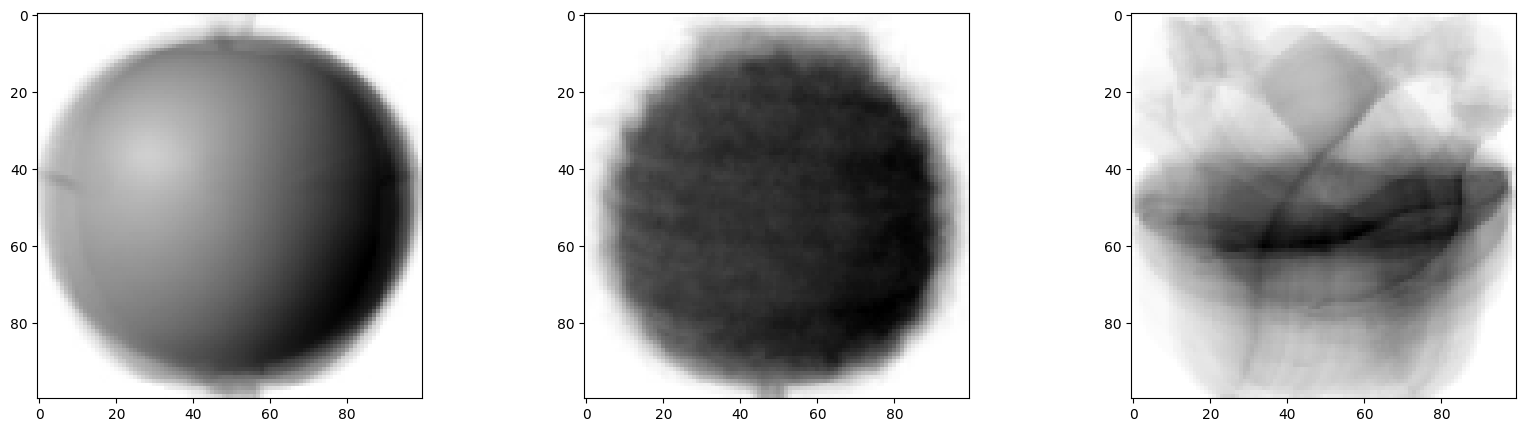

In [58]:
fig, axs=plt.subplots(1,3,figsize=(20,5))
axs[0].imshow(apple_mean,cmap='gray_r')
axs[1].imshow(pineapple_mean,cmap='gray_r')
axs[2].imshow(banana_mean,cmap='gray_r')